# EDA — Online Retail Customer Churn

Stage 3: statistical exploration of the RFM feature set
(`data/processed/online_retail_features.csv`) before modeling.

Recall the setup: features are built from transactions before a cutoff
date (2011-09-10); the Churned label reflects whether the customer made
a purchase in the following 90 days. 3,370 customers, 43.0% churn rate.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

df = pd.read_csv("../data/processed/online_retail_features.csv")
print(df.shape)
df.head()


(3370, 9)


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,TenureDays,AvgOrderValue,CancellationRate,Churned
0,12346,235,1,77183.60,1,0,77183.600000,0.500000,1
1,12347,39,5,2790.86,82,237,558.172000,0.000000,0
2,12348,158,3,1487.24,22,109,495.746667,0.000000,0
3,12350,219,1,334.40,17,0,334.400000,0.000000,1
4,12352,171,5,1561.81,26,34,312.362000,0.208333,0


## 1. Baseline churn rate and class balance

Baseline churn rate: 0.4300 (43.00%)


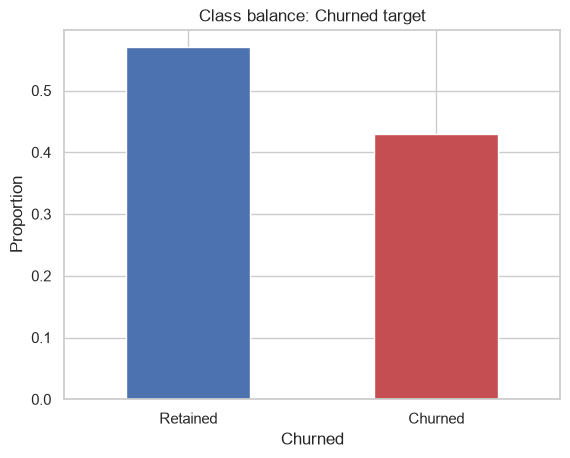

In [2]:
baseline_rate = df["Churned"].mean()
print(f"Baseline churn rate: {baseline_rate:.4f} ({baseline_rate*100:.2f}%)")

ax = df["Churned"].value_counts(normalize=True).sort_index().plot(
    kind="bar", color=["#4C72B0", "#C44E52"]
)
ax.set_xticklabels(["Retained", "Churned"], rotation=0)
ax.set_ylabel("Proportion")
ax.set_title("Class balance: Churned target")
plt.show()


## 2. Recency vs Churn

Hypothesis: customers who haven't purchased recently (higher Recency) are
more likely to churn. Testing with Mann-Whitney U (non-parametric — RFM
distributions are typically right-skewed, not normal, so a t-test's
normality assumption is questionable here).


C:\Users\ACSJR-65\AppData\Local\Temp\ipykernel_14668\3382111620.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Retained", "Churned"])


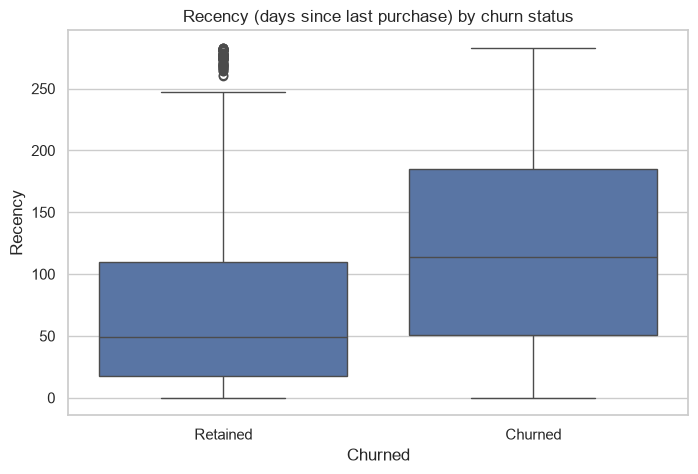

Mann-Whitney U: statistic=881734.0, p-value=1.24e-74
Median Recency — Retained: 49 days, Churned: 114 days


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="Churned", y="Recency", ax=ax)
ax.set_xticklabels(["Retained", "Churned"])
ax.set_title("Recency (days since last purchase) by churn status")
plt.show()

recency_retained = df.loc[df["Churned"] == 0, "Recency"]
recency_churned = df.loc[df["Churned"] == 1, "Recency"]
stat, p_value = stats.mannwhitneyu(recency_retained, recency_churned, alternative="less")
print(f"Mann-Whitney U: statistic={stat:.1f}, p-value={p_value:.2e}")
print(f"Median Recency — Retained: {recency_retained.median():.0f} days, "
      f"Churned: {recency_churned.median():.0f} days")


## 3. Frequency vs Churn

Hypothesis: customers with more historical purchases (higher Frequency)
are less likely to churn — loyalty/habit effect.


C:\Users\ACSJR-65\AppData\Local\Temp\ipykernel_14668\3176227800.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Retained", "Churned"])


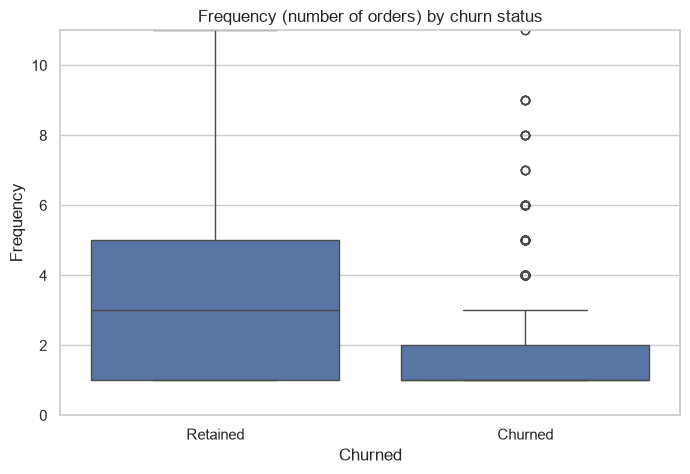

Mann-Whitney U: statistic=2008705.5, p-value=6.62e-117
Median Frequency — Retained: 3, Churned: 1


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="Churned", y="Frequency", ax=ax)
ax.set_xticklabels(["Retained", "Churned"])
ax.set_ylim(0, df["Frequency"].quantile(0.95))  # clip extreme outliers for readability
ax.set_title("Frequency (number of orders) by churn status")
plt.show()

freq_retained = df.loc[df["Churned"] == 0, "Frequency"]
freq_churned = df.loc[df["Churned"] == 1, "Frequency"]
stat, p_value = stats.mannwhitneyu(freq_retained, freq_churned, alternative="greater")
print(f"Mann-Whitney U: statistic={stat:.1f}, p-value={p_value:.2e}")
print(f"Median Frequency — Retained: {freq_retained.median():.0f}, "
      f"Churned: {freq_churned.median():.0f}")


## 4. Monetary value vs Churn

Hypothesis: higher-spending customers are less likely to churn.


C:\Users\ACSJR-65\AppData\Local\Temp\ipykernel_14668\726554982.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Retained", "Churned"])


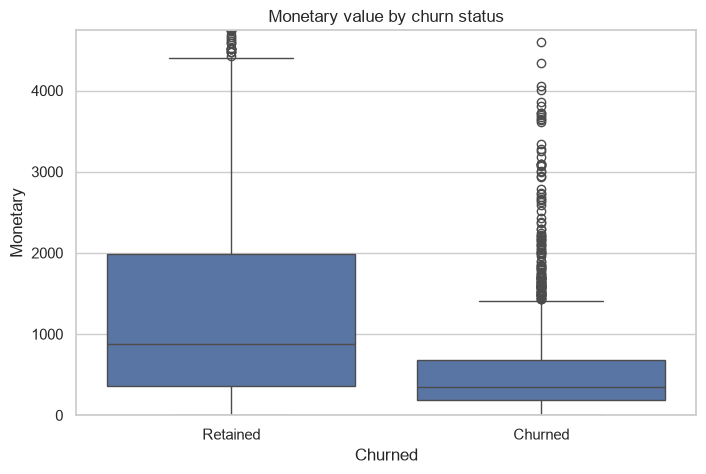

Mann-Whitney U: statistic=1978825.0, p-value=3.72e-98
Median Monetary — Retained: £872.13, Churned: £348.15


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="Churned", y="Monetary", ax=ax)
ax.set_xticklabels(["Retained", "Churned"])
ax.set_ylim(0, df["Monetary"].quantile(0.95))
ax.set_title("Monetary value by churn status")
plt.show()

mon_retained = df.loc[df["Churned"] == 0, "Monetary"]
mon_churned = df.loc[df["Churned"] == 1, "Monetary"]
stat, p_value = stats.mannwhitneyu(mon_retained, mon_churned, alternative="greater")
print(f"Mann-Whitney U: statistic={stat:.1f}, p-value={p_value:.2e}")
print(f"Median Monetary — Retained: £{mon_retained.median():.2f}, "
      f"Churned: £{mon_churned.median():.2f}")


## 5. Cancellation rate vs Churn

Does a customer's return/cancellation behavior predict churn? Two
plausible directions: high cancellers might be dissatisfied (more likely
to churn), or might just be active, engaged shoppers who buy and return
a lot (less likely to churn). Worth checking rather than assuming.


In [6]:
cancel_retained = df.loc[df["Churned"] == 0, "CancellationRate"]
cancel_churned = df.loc[df["Churned"] == 1, "CancellationRate"]
stat, p_value = stats.mannwhitneyu(cancel_retained, cancel_churned, alternative="two-sided")
print(f"Mann-Whitney U (two-sided): statistic={stat:.1f}, p-value={p_value:.2e}")
print(f"Mean CancellationRate — Retained: {cancel_retained.mean():.4f}, "
      f"Churned: {cancel_churned.mean():.4f}")


Mann-Whitney U (two-sided): statistic=1645331.0, p-value=1.32e-26
Mean CancellationRate — Retained: 0.0257, Churned: 0.0265


## 6. Correlation matrix (RFM + engineered features)

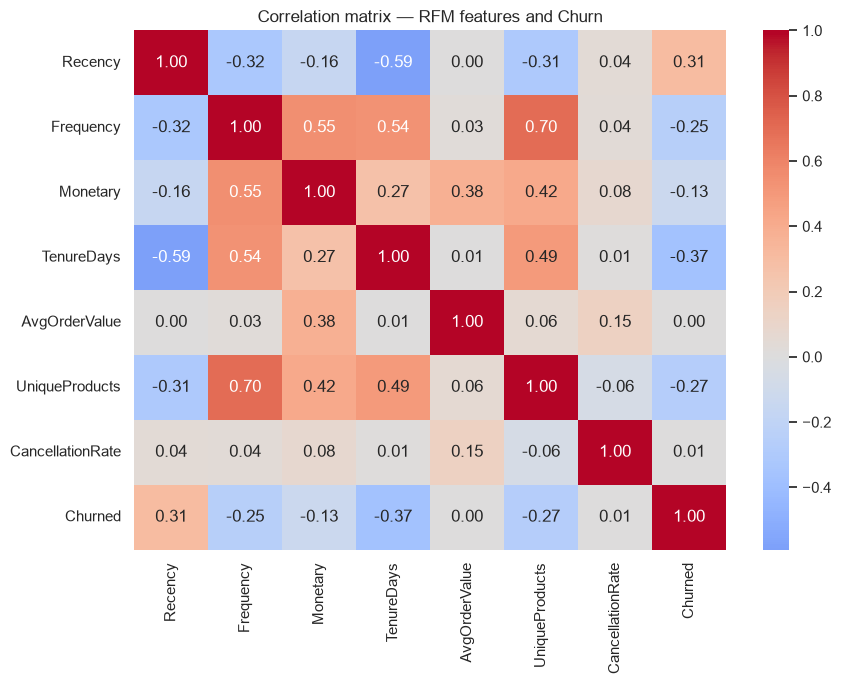

In [7]:
numeric_cols = ["Recency", "Frequency", "Monetary", "TenureDays",
                 "AvgOrderValue", "UniqueProducts", "CancellationRate", "Churned"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — RFM features and Churn")
plt.tight_layout()
plt.show()


## Summary of findings

_Fill in after running each cell above — becomes the README's key-insights
section._

- Baseline churn rate: 43.0% (well-balanced relative to Project 1)
- Recency: [state direction/significance from Mann-Whitney test]
- Frequency: [state direction/significance]
- Monetary: [state direction/significance]
- Cancellation rate: [state finding — confirm which direction, if any]
- Strongest correlate(s) with Churned: [read off the correlation heatmap]

**Implications for modeling:** classic RFM theory predicts Recency should
be the dominant driver (a customer who bought recently is, almost by
construction, less likely to have already churned within a 90-day
window) — worth confirming whether the data bears this out or whether
Frequency/Monetary contribute meaningfully beyond what Recency alone
captures.
